# <u>Preprocesamiento y revisión de variables</u>

## Funnel de Modelamiento

### Importación de librerías iniciales

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [41]:
seed = 2021

### 1. Lectura de base

In [42]:
data_vivienda = pd.read_csv('data/bostonvivienda.csv')

In [43]:
data_vivienda.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,medv
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [44]:
data_vivienda.shape

(506, 13)

Definimos 2 columnas relevantes, el id y el target, que en nuestro caso son las siguientes variables:

In [45]:
target = 'medv'

la variable target es numerica se queda tal cual

algunas características de nuestra variable target:

In [46]:
data_vivienda[target].value_counts(normalize = True) #nos da la frecuencia relativa

50.0    0.031621
25.0    0.015810
21.7    0.013834
22.0    0.013834
23.1    0.013834
          ...   
14.2    0.001976
26.7    0.001976
32.9    0.001976
39.8    0.001976
9.7     0.001976
Name: medv, Length: 229, dtype: float64

In [47]:
data_vivienda[target].mean() #media

22.532806324110698

### 2.División en conjuntos de entrenamiento y prueba

In [48]:
X = data_vivienda.drop(target, axis =1)
y = data_vivienda[target]

In [49]:
X.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [50]:
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: medv, dtype: float64

In [51]:
X.shape

(506, 12)

In [52]:
y.shape

(506,)

In [53]:
#función para dividir la base en piloto y control
from sklearn.model_selection import train_test_split

In [54]:
seed

2021

In [55]:
# usaremos la división train/test en 80/20. Otro ratio recomendable es 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = seed)
#stratify es para mantener la misma proporción de datos en el train y test

In [56]:
X_train.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat
28,0.77299,0.0,8.14,0.538,6.495,94.4,4.4547,4,307,21.0,387.94,12.80
498,0.23912,0.0,9.69,0.585,6.019,65.3,2.4091,6,391,19.2,396.90,12.92
284,0.00906,90.0,2.97,0.400,7.088,20.8,7.3073,1,285,15.3,394.72,7.85
414,45.74610,0.0,18.10,0.693,4.519,100.0,1.6582,24,666,20.2,88.27,36.98
123,0.15038,0.0,25.65,0.581,5.856,97.0,1.9444,2,188,19.1,370.31,25.41


In [57]:
X_test.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat
210,0.17446,0.0,10.59,0.489,5.960,92.1,3.8771,4,277,18.6,393.25,17.27
24,0.75026,0.0,8.14,0.538,5.924,94.1,4.3996,4,307,21.0,394.33,16.30
36,0.09744,0.0,5.96,0.499,5.841,61.4,3.3779,5,279,19.2,377.56,11.41
439,9.39063,0.0,18.10,0.740,5.627,93.9,1.8172,24,666,20.2,396.90,22.88
161,1.46336,0.0,19.58,0.605,7.489,90.8,1.9709,5,403,14.7,374.43,1.73


In [58]:
X_train.shape, X_test.shape

((404, 12), (102, 12))

In [59]:
y_train.shape, y_test.shape

((404,), (102,))

In [60]:
# validación de los promedios de la variable target
y.mean(), y_train.mean(), y_test.mean()

(22.532806324110698, 22.548019801980203, 22.47254901960784)

In [61]:
y_train.value_counts()

50.0    14
22.0     7
21.7     6
19.6     5
13.8     5
        ..
29.6     1
43.5     1
15.7     1
7.5      1
27.0     1
Name: medv, Length: 208, dtype: int64

In [62]:
y_test.value_counts()

20.0    4
25.0    3
21.1    2
23.8    2
21.4    2
       ..
22.4    1
13.9    1
48.8    1
23.2    1
9.7     1
Name: medv, Length: 83, dtype: int64

### 3.Análisis exploratorio

Revisemos las columnas del conjunto de datos:

In [63]:
X_train.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat
28,0.77299,0.0,8.14,0.538,6.495,94.4,4.4547,4,307,21.0,387.94,12.80
498,0.23912,0.0,9.69,0.585,6.019,65.3,2.4091,6,391,19.2,396.90,12.92
284,0.00906,90.0,2.97,0.400,7.088,20.8,7.3073,1,285,15.3,394.72,7.85
414,45.74610,0.0,18.10,0.693,4.519,100.0,1.6582,24,666,20.2,88.27,36.98
123,0.15038,0.0,25.65,0.581,5.856,97.0,1.9444,2,188,19.1,370.31,25.41


In [64]:
X_train.dtypes

crim        float64
zn          float64
indus       float64
nox         float64
rm          float64
edad        float64
dis         float64
rad           int64
impuesto      int64
ptratio     float64
negro       float64
lstat       float64
dtype: object

In [65]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 404 entries, 28 to 116
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   crim      404 non-null    float64
 1   zn        404 non-null    float64
 2   indus     404 non-null    float64
 3   nox       404 non-null    float64
 4   rm        404 non-null    float64
 5   edad      404 non-null    float64
 6   dis       404 non-null    float64
 7   rad       404 non-null    int64  
 8   impuesto  404 non-null    int64  
 9   ptratio   404 non-null    float64
 10  negro     404 non-null    float64
 11  lstat     404 non-null    float64
dtypes: float64(10), int64(2)
memory usage: 41.0 KB


In [66]:
X_train.describe()   # sólo para variables numéricas

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,3.977309,11.554455,11.265817,0.558209,6.280809,69.097525,3.773607,9.871287,415.094059,18.465347,355.730371,12.670743
std,9.354535,23.785294,7.014753,0.119549,0.704683,27.961913,2.135579,8.874827,171.742901,2.185331,92.737133,7.198516
min,0.009060,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.920000
25%,0.082973,0.000000,5.130000,0.448000,5.887750,45.800000,2.077100,4.000000,284.000000,17.375000,375.472500,6.840000
50%,0.294545,0.000000,9.690000,0.538000,6.208500,78.500000,3.079300,5.000000,341.000000,19.100000,391.305000,11.490000
75%,4.128648,12.500000,18.100000,0.635000,6.626000,94.325000,5.234500,24.000000,666.000000,20.200000,396.215000,16.910000
max,88.976200,100.000000,27.740000,0.871000,8.725000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000


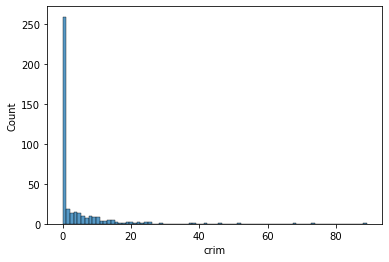

In [67]:
sns.histplot(data = X_train, x = 'crim') #verificar atipicos
plt.show()

In [68]:
X_train['crim'].value_counts(normalize = True) #nos da la frecuencia relativa

0.01501    0.004950
0.12269    0.002475
1.38799    0.002475
5.20177    0.002475
0.10659    0.002475
             ...   
2.30040    0.002475
0.36894    0.002475
0.14231    0.002475
0.25356    0.002475
8.24809    0.002475
Name: crim, Length: 403, dtype: float64

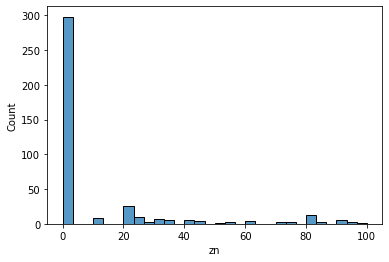

In [69]:
sns.histplot(data = X_train, x = 'zn') #verificar atipicos
plt.show()

In [296]:
X_train['zn'].value_counts(normalize = True) #nos da la frecuencia relativa

0.0      0.737624
20.0     0.039604
80.0     0.029703
25.0     0.024752
12.5     0.019802
22.0     0.017327
40.0     0.014851
90.0     0.012376
45.0     0.009901
60.0     0.009901
30.0     0.009901
95.0     0.007426
28.0     0.007426
21.0     0.007426
75.0     0.007426
35.0     0.007426
70.0     0.007426
33.0     0.007426
85.0     0.004950
34.0     0.004950
55.0     0.004950
82.5     0.002475
100.0    0.002475
52.5     0.002475
Name: zn, dtype: float64

verificar nulos

In [71]:
X_train.isnull().sum() #sumar nulos

crim        0
zn          0
indus       0
nox         0
rm          0
edad        0
dis         0
rad         0
impuesto    0
ptratio     0
negro       0
lstat       0
dtype: int64

guardar el avance

In [72]:
# punto de guardado de bases avanzadas

X_train.to_csv('train_01.csv', index = False)
X_test.to_csv('test_01.csv', index = False)

y_train.to_csv('ytrain_01.csv', index = False)
y_test.to_csv('ytest_01.csv', index = False)

In [73]:
# extrayendo la data guardada
import pandas as pd

X_train = pd.read_csv('train_01.csv')
X_test = pd.read_csv('test_01.csv')

y_train = pd.read_csv('ytrain_01.csv')
y_test = pd.read_csv('ytest_01.csv')

verificar atipicos

In [74]:
X_train.describe(percentiles = [ 0.75,0.85,0.95,0.99,1])

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,3.977309,11.554455,11.265817,0.558209,6.280809,69.097525,3.773607,9.871287,415.094059,18.465347,355.730371,12.670743
std,9.354535,23.785294,7.014753,0.119549,0.704683,27.961913,2.135579,8.874827,171.742901,2.185331,92.737133,7.198516
min,0.009060,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.920000
50%,0.294545,0.000000,9.690000,0.538000,6.208500,78.500000,3.079300,5.000000,341.000000,19.100000,391.305000,11.490000
75%,4.128648,12.500000,18.100000,0.635000,6.626000,94.325000,5.234500,24.000000,666.000000,20.200000,396.215000,16.910000
85%,8.258628,28.000000,18.100000,0.696850,6.875400,97.355000,6.248810,24.000000,666.000000,20.200000,396.900000,19.734000
95%,18.403475,80.000000,21.890000,0.770000,7.639750,100.000000,7.935835,24.000000,666.000000,21.000000,396.900000,27.194000
99%,45.619593,90.000000,27.677300,0.871000,8.265790,100.000000,9.220300,24.000000,709.650000,21.200000,396.900000,33.959100
100%,88.976200,100.000000,27.740000,0.871000,8.725000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000


**Variable `ApplicantIncome`**

In [75]:
import numpy as np

p1 = np.percentile(X_train['crim'], 1)
p99 = np.percentile(X_train['crim'], 99)
p1, p99

(0.0136063, 45.619592999999874)

`np.clip` limita los bordes del intervalo a unos valores dados

In [76]:
X_train['crim'] = np.clip(X_train['crim'], p1, p99)

Veamos los cambios en la distribución:

In [77]:
X_train.describe(percentiles = [0.73, 0.75, 0.9, 0.95, 0.975, 0.99])

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,3.731748,11.554455,11.265817,0.558209,6.280809,69.097525,3.773607,9.871287,415.094059,18.465347,355.730371,12.670743
std,7.683429,23.785294,7.014753,0.119549,0.704683,27.961913,2.135579,8.874827,171.742901,2.185331,92.737133,7.198516
min,0.013606,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.920000
50%,0.294545,0.000000,9.690000,0.538000,6.208500,78.500000,3.079300,5.000000,341.000000,19.100000,391.305000,11.490000
73%,3.674535,0.000000,18.100000,0.624000,6.590570,93.638000,5.103497,24.000000,666.000000,20.200000,395.701400,16.363300
75%,4.128648,12.500000,18.100000,0.635000,6.626000,94.325000,5.234500,24.000000,666.000000,20.200000,396.215000,16.910000
90%,11.101890,43.500000,19.580000,0.713000,7.152900,98.800000,6.817360,24.000000,666.000000,20.900000,396.900000,23.183000
95%,18.403475,80.000000,21.890000,0.770000,7.639750,100.000000,7.935835,24.000000,666.000000,21.000000,396.900000,27.194000
97.5%,25.027770,84.812500,25.368000,0.871000,7.928550,100.000000,8.784937,24.000000,666.000000,21.200000,396.900000,30.543500


In [78]:
#variable da indice de criminalidad
X_train['Índice_de_criminalidad'] = X_train['crim']*(1-X_train['zn'])

In [79]:
X_train.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad
0,0.772990,0.0,8.14,0.538,6.495,94.4,4.4547,4,307,21.0,387.94,12.80,0.772990
1,0.239120,0.0,9.69,0.585,6.019,65.3,2.4091,6,391,19.2,396.90,12.92,0.239120
2,0.013606,90.0,2.97,0.400,7.088,20.8,7.3073,1,285,15.3,394.72,7.85,-1.210961
3,45.619593,0.0,18.10,0.693,4.519,100.0,1.6582,24,666,20.2,88.27,36.98,45.619593
4,0.150380,0.0,25.65,0.581,5.856,97.0,1.9444,2,188,19.1,370.31,25.41,0.150380


In [80]:
#esta variable nos da el indice de calidad de vida
X_train['In_calidad_vida'] =0.3*(1-X_train['nox'])+0.3*(X_train['rad'])+0.3*(1-X_train['ptratio'])+0.3*(1-X_train['lstat'])

In [81]:
X_train.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida
0,0.772990,0.0,8.14,0.538,6.495,94.4,4.4547,4,307,21.0,387.94,12.80,0.772990,-8.2014
1,0.239120,0.0,9.69,0.585,6.019,65.3,2.4091,6,391,19.2,396.90,12.92,0.239120,-7.1115
2,0.013606,90.0,2.97,0.400,7.088,20.8,7.3073,1,285,15.3,394.72,7.85,-1.210961,-5.8650
3,45.619593,0.0,18.10,0.693,4.519,100.0,1.6582,24,666,20.2,88.27,36.98,45.619593,-9.2619
4,0.150380,0.0,25.65,0.581,5.856,97.0,1.9444,2,188,19.1,370.31,25.41,0.150380,-12.0273


In [82]:
X_train.describe()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,3.731748,11.554455,11.265817,0.558209,6.280809,69.097525,3.773607,9.871287,415.094059,18.465347,355.730371,12.670743,2.824451,-5.646903
std,7.683429,23.785294,7.014753,0.119549,0.704683,27.961913,2.135579,8.874827,171.742901,2.185331,92.737133,7.198516,8.404785,2.387228
min,0.013606,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.920000,-15.679940,-13.016700
25%,0.082973,0.000000,5.130000,0.448000,5.887750,45.800000,2.077100,4.000000,284.000000,17.375000,375.472500,6.840000,-0.745118,-7.111950
50%,0.294545,0.000000,9.690000,0.538000,6.208500,78.500000,3.079300,5.000000,341.000000,19.100000,391.305000,11.490000,0.240075,-5.529750
75%,4.128648,12.500000,18.100000,0.635000,6.626000,94.325000,5.234500,24.000000,666.000000,20.200000,396.215000,16.910000,4.128648,-3.941550
max,45.619593,100.000000,27.740000,0.871000,8.725000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,45.619593,0.962700


In [84]:
#x_train = x_train.drop("log_edad", axis=1)
#eliminar log_edad

In [83]:
X_train['log_dis'] = np.log(X_train['dis'])

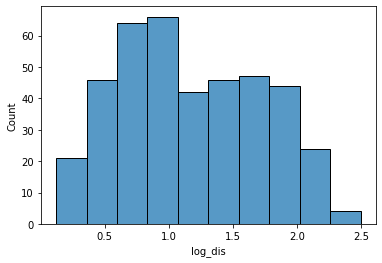

In [86]:
sns.histplot(X_train['log_dis'])
plt.show()

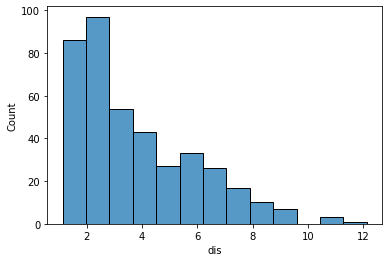

In [87]:
sns.histplot(X_train['dis'])
plt.show()

In [85]:
X_train.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis
0,0.772990,0.0,8.14,0.538,6.495,94.4,4.4547,4,307,21.0,387.94,12.80,0.772990,-8.2014,1.493960
1,0.239120,0.0,9.69,0.585,6.019,65.3,2.4091,6,391,19.2,396.90,12.92,0.239120,-7.1115,0.879253
2,0.013606,90.0,2.97,0.400,7.088,20.8,7.3073,1,285,15.3,394.72,7.85,-1.210961,-5.8650,1.988874
3,45.619593,0.0,18.10,0.693,4.519,100.0,1.6582,24,666,20.2,88.27,36.98,45.619593,-9.2619,0.505733
4,0.150380,0.0,25.65,0.581,5.856,97.0,1.9444,2,188,19.1,370.31,25.41,0.150380,-12.0273,0.664953


In [88]:
# punto de guardado de bases avanzadas

X_train.to_csv('train_02.csv', index = False)
y_train.to_csv('ytrain_02.csv', index = False)

In [89]:
# extrayendo la data guardada
import pandas as pd

X_train = pd.read_csv('train_02.csv')
y_train = pd.read_csv('ytrain_02.csv')

### 10.Estandarización

Esto es importante para variables con diferencias en escala, y siempre tiene que aplicarse en ML no supervisado

In [90]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler() #escala de 0 a 1 los datos

In [91]:
X_scaled = scaler.fit_transform(X_train)

In [93]:
X_train_scaled = pd.DataFrame(data = X_scaled, columns = columnas)

X_train_scaled

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis
0,0.016651,0.00,0.281525,0.314815,0.568164,0.942327,0.302367,0.130435,0.229008,0.893617,0.977407,0.301803,0.268402,0.344457,0.578083
1,0.004945,0.00,0.338343,0.411523,0.475988,0.642636,0.116351,0.217391,0.389313,0.702128,1.000000,0.305132,0.259693,0.422422,0.319098
2,0.000000,0.90,0.092009,0.030864,0.682998,0.184346,0.561767,0.000000,0.187023,0.287234,0.994503,0.164494,0.236037,0.511588,0.786597
3,1.000000,0.00,0.646628,0.633745,0.185515,1.000000,0.048068,1.000000,0.914122,0.808511,0.221771,0.972538,1.000000,0.268595,0.161729
4,0.002999,0.00,0.923387,0.403292,0.444423,0.969104,0.074094,0.043478,0.001908,0.691489,0.932952,0.651595,0.258245,0.070776,0.228811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,0.005482,0.00,0.296921,0.277778,0.516654,0.909372,0.128718,0.173913,0.375954,0.882979,0.985703,0.378086,0.260093,0.309434,0.342236
400,0.006837,0.00,0.785557,0.491770,0.555771,0.987642,0.062099,0.130435,0.477099,0.914894,1.000000,0.373648,0.261101,0.282737,0.199215
401,0.000016,1.00,0.031525,0.053498,0.630325,0.387230,0.654293,0.173913,0.131679,0.265957,0.989914,0.056311,0.232665,0.685180,0.841521
402,0.000000,0.35,0.038856,0.117284,0.712626,0.477858,0.537270,0.000000,0.185115,0.308511,0.994553,0.099029,0.248245,0.557041,0.770770


verificar despues de escalizar los datos de las nuevas variables ya no son negativas

In [94]:
X_train_scaled.describe()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,0.081527,0.115545,0.396108,0.356398,0.526687,0.681746,0.240432,0.385708,0.435294,0.623973,0.896188,0.298218,0.301868,0.527190,0.444546
std,0.168474,0.237853,0.257139,0.245986,0.136461,0.287970,0.194198,0.385862,0.327754,0.232482,0.233842,0.199681,0.137110,0.170768,0.231265
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.001521,0.000000,0.171188,0.129630,0.450571,0.441813,0.086161,0.130435,0.185115,0.507979,0.945969,0.136477,0.243637,0.422389,0.256625
50%,0.006160,0.000000,0.338343,0.314815,0.512684,0.778579,0.177295,0.173913,0.293893,0.691489,0.985892,0.265465,0.259709,0.535570,0.422506
75%,0.090230,0.125000,0.646628,0.514403,0.593532,0.941555,0.373278,1.000000,0.914122,0.808511,0.998273,0.415811,0.323144,0.649180,0.646045
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [92]:
columnas = X_train.columns
columnas

Index(['crim', 'zn', 'indus', 'nox', 'rm', 'edad', 'dis', 'rad', 'impuesto',
       'ptratio', 'negro', 'lstat', 'Índice_de_criminalidad',
       'In_calidad_vida', 'log_dis'],
      dtype='object')

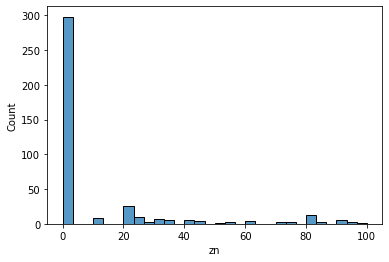

In [95]:
sns.histplot(X_train['zn'])
plt.show()

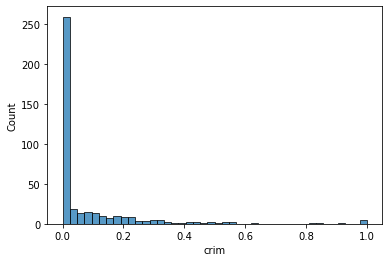

In [96]:
sns.histplot(X_train_scaled['crim'])
plt.show()

In [97]:
# punto de guardado de bases avanzadas

X_train_scaled.to_csv('train_escaled_101122.csv', index = False)

In [98]:
# extrayendo la data guardada
import pandas as pd

X_train_scaled = pd.read_csv('train_escaled_101122.csv')

## Repetir todo el preprocesamiento para el conjunto de validación

In [99]:
X_test.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat
0,0.17446,0.0,10.59,0.489,5.960,92.1,3.8771,4,277,18.6,393.25,17.27
1,0.75026,0.0,8.14,0.538,5.924,94.1,4.3996,4,307,21.0,394.33,16.30
2,0.09744,0.0,5.96,0.499,5.841,61.4,3.3779,5,279,19.2,377.56,11.41
3,9.39063,0.0,18.10,0.740,5.627,93.9,1.8172,24,666,20.2,396.90,22.88
4,1.46336,0.0,19.58,0.605,7.489,90.8,1.9709,5,403,14.7,374.43,1.73


In [100]:
X_train.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis
0,0.772990,0.0,8.14,0.538,6.495,94.4,4.4547,4,307,21.0,387.94,12.80,0.772990,-8.2014,1.493960
1,0.239120,0.0,9.69,0.585,6.019,65.3,2.4091,6,391,19.2,396.90,12.92,0.239120,-7.1115,0.879253
2,0.013606,90.0,2.97,0.400,7.088,20.8,7.3073,1,285,15.3,394.72,7.85,-1.210961,-5.8650,1.988874
3,45.619593,0.0,18.10,0.693,4.519,100.0,1.6582,24,666,20.2,88.27,36.98,45.619593,-9.2619,0.505733
4,0.150380,0.0,25.65,0.581,5.856,97.0,1.9444,2,188,19.1,370.31,25.41,0.150380,-12.0273,0.664953


In [101]:
X_test.shape

(102, 12)

In [102]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   crim      102 non-null    float64
 1   zn        102 non-null    float64
 2   indus     102 non-null    float64
 3   nox       102 non-null    float64
 4   rm        102 non-null    float64
 5   edad      102 non-null    float64
 6   dis       102 non-null    float64
 7   rad       102 non-null    int64  
 8   impuesto  102 non-null    int64  
 9   ptratio   102 non-null    float64
 10  negro     102 non-null    float64
 11  lstat     102 non-null    float64
dtypes: float64(10), int64(2)
memory usage: 9.7 KB


In [103]:
X_test['crim'] = np.clip(X_test['crim'], p1, p99)

In [104]:
X_train.describe(percentiles = [0.73, 0.75, 0.9, 0.95, 0.975, 0.99])

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,3.731748,11.554455,11.265817,0.558209,6.280809,69.097525,3.773607,9.871287,415.094059,18.465347,355.730371,12.670743,2.824451,-5.646903,1.177007
std,7.683429,23.785294,7.014753,0.119549,0.704683,27.961913,2.135579,8.874827,171.742901,2.185331,92.737133,7.198516,8.404785,2.387228,0.548915
min,0.013606,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.920000,-15.679940,-13.016700,0.121864
50%,0.294545,0.000000,9.690000,0.538000,6.208500,78.500000,3.079300,5.000000,341.000000,19.100000,391.305000,11.490000,0.240075,-5.529750,1.124694
73%,3.674535,0.000000,18.100000,0.624000,6.590570,93.638000,5.103497,24.000000,666.000000,20.200000,395.701400,16.363300,3.674535,-4.041402,1.629925
75%,4.128648,12.500000,18.100000,0.635000,6.626000,94.325000,5.234500,24.000000,666.000000,20.200000,396.215000,16.910000,4.128648,-3.941550,1.655271
90%,11.101890,43.500000,19.580000,0.713000,7.152900,98.800000,6.817360,24.000000,666.000000,20.900000,396.900000,23.183000,11.101890,-2.821830,1.919472
95%,18.403475,80.000000,21.890000,0.770000,7.639750,100.000000,7.935835,24.000000,666.000000,21.000000,396.900000,27.194000,18.403475,-2.129925,2.071372
97.5%,25.027770,84.812500,25.368000,0.871000,7.928550,100.000000,8.784937,24.000000,666.000000,21.200000,396.900000,30.543500,25.027770,-1.252567,2.173034


In [105]:
#variable da indice de criminalidad
X_test['Índice_de_criminalidad'] = X_train['crim']*(1-X_train['zn'])
#esta variable nos da el indice de calidad de vida
X_test['In_calidad_vida'] =0.3*(1-X_train['nox'])+0.3*(X_train['rad'])+0.3*(1-X_train['ptratio'])+0.3*(1-X_train['lstat'])

In [106]:
X_test['log_dis'] = np.log(X_test['dis'])

In [107]:
X_test_scaled = pd.DataFrame(data = scaler.fit_transform(X_test), columns = X_test.columns)

In [108]:
X_train_scaled.shape

(404, 15)

In [109]:
X_test_scaled.shape

(102, 15)

In [110]:
X_train_scaled.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis
0,0.016651,0.0,0.281525,0.314815,0.568164,0.942327,0.302367,0.130435,0.229008,0.893617,0.977407,0.301803,0.268402,0.344457,0.578083
1,0.004945,0.0,0.338343,0.411523,0.475988,0.642636,0.116351,0.217391,0.389313,0.702128,1.000000,0.305132,0.259693,0.422422,0.319098
2,0.000000,0.9,0.092009,0.030864,0.682998,0.184346,0.561767,0.000000,0.187023,0.287234,0.994503,0.164494,0.236037,0.511588,0.786597
3,1.000000,0.0,0.646628,0.633745,0.185515,1.000000,0.048068,1.000000,0.914122,0.808511,0.221771,0.972538,1.000000,0.268595,0.161729
4,0.002999,0.0,0.923387,0.403292,0.444423,0.969104,0.074094,0.043478,0.001908,0.691489,0.932952,0.651595,0.258245,0.070776,0.228811


guardamos ambos dataset

In [111]:
target = 'medv'

X_train_export = X_train_scaled.copy()
X_train_export[target] = y_train.values

X_test_export = X_test_scaled.copy()
X_test_export[target] = y_test.values

In [112]:
X_train_export.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis,medv
0,0.016651,0.0,0.281525,0.314815,0.568164,0.942327,0.302367,0.130435,0.229008,0.893617,0.977407,0.301803,0.268402,0.344457,0.578083,18.4
1,0.004945,0.0,0.338343,0.411523,0.475988,0.642636,0.116351,0.217391,0.389313,0.702128,1.000000,0.305132,0.259693,0.422422,0.319098,21.2
2,0.000000,0.9,0.092009,0.030864,0.682998,0.184346,0.561767,0.000000,0.187023,0.287234,0.994503,0.164494,0.236037,0.511588,0.786597,32.2
3,1.000000,0.0,0.646628,0.633745,0.185515,1.000000,0.048068,1.000000,0.914122,0.808511,0.221771,0.972538,1.000000,0.268595,0.161729,7.0
4,0.002999,0.0,0.923387,0.403292,0.444423,0.969104,0.074094,0.043478,0.001908,0.691489,0.932952,0.651595,0.258245,0.070776,0.228811,17.3


In [113]:
X_test_export.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis,medv
0,0.008901,0.0,0.379481,0.192389,0.426480,0.915778,0.274024,0.130435,0.186192,0.622222,0.990718,0.475520,0.229788,0.341191,0.513172,21.7
1,0.040764,0.0,0.278533,0.295983,0.419158,0.937100,0.330567,0.130435,0.248954,0.888889,0.993465,0.445838,0.220619,0.419544,0.574449,15.6
2,0.004639,0.0,0.188710,0.213531,0.402278,0.588486,0.220003,0.173913,0.190377,0.688889,0.950820,0.296206,0.195715,0.509155,0.446366,20.0
3,0.518899,0.0,0.688916,0.723044,0.358755,0.934968,0.051110,1.000000,1.000000,0.800000,1.000000,0.647185,1.000000,0.264951,0.145880,12.8
4,0.080225,0.0,0.749897,0.437632,0.737442,0.901919,0.067743,0.173913,0.449791,0.188889,0.942861,0.000000,0.219095,0.066146,0.185233,50.0


In [114]:
# punto de guardado de bases avanzadas
X_train_export.to_csv('train_preprocesed.csv', index = False)
X_test_export.to_csv('test_preprocesed.csv', index = False)

Cargamos de nuevo las bases para continuar:

In [115]:
import pandas as pd
import numpy as np

X_train_export = pd.read_csv('train_preprocesed.csv')
X_test_export = pd.read_csv('test_preprocesed.csv')

target = 'medv'

In [116]:
X_train_export.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis,medv
0,0.016651,0.0,0.281525,0.314815,0.568164,0.942327,0.302367,0.130435,0.229008,0.893617,0.977407,0.301803,0.268402,0.344457,0.578083,18.4
1,0.004945,0.0,0.338343,0.411523,0.475988,0.642636,0.116351,0.217391,0.389313,0.702128,1.000000,0.305132,0.259693,0.422422,0.319098,21.2
2,0.000000,0.9,0.092009,0.030864,0.682998,0.184346,0.561767,0.000000,0.187023,0.287234,0.994503,0.164494,0.236037,0.511588,0.786597,32.2
3,1.000000,0.0,0.646628,0.633745,0.185515,1.000000,0.048068,1.000000,0.914122,0.808511,0.221771,0.972538,1.000000,0.268595,0.161729,7.0
4,0.002999,0.0,0.923387,0.403292,0.444423,0.969104,0.074094,0.043478,0.001908,0.691489,0.932952,0.651595,0.258245,0.070776,0.228811,17.3


separamos del target

In [117]:
X_train_scaled = X_train_export.drop(target, axis = 1)  # para borrar columnas
y_train = X_train_export[target]

In [118]:
X_train_scaled.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis
0,0.016651,0.0,0.281525,0.314815,0.568164,0.942327,0.302367,0.130435,0.229008,0.893617,0.977407,0.301803,0.268402,0.344457,0.578083
1,0.004945,0.0,0.338343,0.411523,0.475988,0.642636,0.116351,0.217391,0.389313,0.702128,1.000000,0.305132,0.259693,0.422422,0.319098
2,0.000000,0.9,0.092009,0.030864,0.682998,0.184346,0.561767,0.000000,0.187023,0.287234,0.994503,0.164494,0.236037,0.511588,0.786597
3,1.000000,0.0,0.646628,0.633745,0.185515,1.000000,0.048068,1.000000,0.914122,0.808511,0.221771,0.972538,1.000000,0.268595,0.161729
4,0.002999,0.0,0.923387,0.403292,0.444423,0.969104,0.074094,0.043478,0.001908,0.691489,0.932952,0.651595,0.258245,0.070776,0.228811


In [119]:
X_test_scaled = X_test_export.drop(target, axis = 1)  # para borrar columnas
y_test = X_test_export[target]

In [120]:
X_test_scaled.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis
0,0.008901,0.0,0.379481,0.192389,0.426480,0.915778,0.274024,0.130435,0.186192,0.622222,0.990718,0.475520,0.229788,0.341191,0.513172
1,0.040764,0.0,0.278533,0.295983,0.419158,0.937100,0.330567,0.130435,0.248954,0.888889,0.993465,0.445838,0.220619,0.419544,0.574449
2,0.004639,0.0,0.188710,0.213531,0.402278,0.588486,0.220003,0.173913,0.190377,0.688889,0.950820,0.296206,0.195715,0.509155,0.446366
3,0.518899,0.0,0.688916,0.723044,0.358755,0.934968,0.051110,1.000000,1.000000,0.800000,1.000000,0.647185,1.000000,0.264951,0.145880
4,0.080225,0.0,0.749897,0.437632,0.737442,0.901919,0.067743,0.173913,0.449791,0.188889,0.942861,0.000000,0.219095,0.066146,0.185233


# <u>Métodos Supervisados para Regresión - Introducción</u>

In [121]:
import pandas as pd
import numpy as np
#import sklearn

import seaborn as sns
sns.set()

import matplotlib.pyplot as plt

In [12]:
X_train_export.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis,medv
0,0.016651,0.0,0.281525,0.314815,0.568164,0.942327,0.302367,0.130435,0.229008,0.893617,0.977407,0.301803,0.268402,0.344457,0.578083,18.4
1,0.004945,0.0,0.338343,0.411523,0.475988,0.642636,0.116351,0.217391,0.389313,0.702128,1.000000,0.305132,0.259693,0.422422,0.319098,21.2
2,0.000000,0.9,0.092009,0.030864,0.682998,0.184346,0.561767,0.000000,0.187023,0.287234,0.994503,0.164494,0.236037,0.511588,0.786597,32.2
3,1.000000,0.0,0.646628,0.633745,0.185515,1.000000,0.048068,1.000000,0.914122,0.808511,0.221771,0.972538,1.000000,0.268595,0.161729,7.0
4,0.002999,0.0,0.923387,0.403292,0.444423,0.969104,0.074094,0.043478,0.001908,0.691489,0.932952,0.651595,0.258245,0.070776,0.228811,17.3


In [13]:
X_train_export.shape

(404, 16)

In [14]:
X_train_export.corr() #correlaciones

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis,medv
crim,1.000000,-0.231547,0.451260,0.459431,-0.288268,0.399065,-0.427309,0.693083,0.642874,0.329041,-0.419252,0.538391,0.962655,0.188677,-0.517307,-0.424797
zn,-0.231547,1.000000,-0.535440,-0.521465,0.344034,-0.573572,0.672939,-0.330044,-0.338358,-0.407102,0.178364,-0.423101,-0.332833,0.134290,0.597587,0.373858
indus,0.451260,-0.535440,1.000000,0.765171,-0.414616,0.652778,-0.712682,0.596789,0.728952,0.390534,-0.347090,0.619428,0.521162,-0.013508,-0.762216,-0.484888
nox,0.459431,-0.521465,0.765171,1.000000,-0.351672,0.738444,-0.769248,0.599936,0.658154,0.181371,-0.376447,0.612007,0.473827,0.050629,-0.829524,-0.433230
rm,-0.288268,0.344034,-0.414616,-0.351672,1.000000,-0.271275,0.236376,-0.241962,-0.333335,-0.357203,0.125205,-0.625729,-0.345259,0.399576,0.295639,0.711003
edad,0.399065,-0.573572,0.652778,0.738444,-0.271275,1.000000,-0.762166,0.473810,0.517774,0.282422,-0.275295,0.628061,0.426092,-0.128382,-0.791542,-0.378956
dis,-0.427309,0.672939,-0.712682,-0.769248,0.236376,-0.762166,1.000000,-0.508928,-0.541710,-0.242627,0.288597,-0.513650,-0.467991,-0.024750,0.964598,0.251618
rad,0.693083,-0.330044,0.596789,0.599936,-0.241962,0.473810,-0.508928,1.000000,0.905502,0.480901,-0.433696,0.509528,0.694987,0.513273,-0.568954,-0.365453
impuesto,0.642874,-0.338358,0.728952,0.658154,-0.333335,0.517774,-0.541710,0.905502,1.000000,0.479624,-0.428394,0.569635,0.664882,0.352982,-0.620967,-0.465480
ptratio,0.329041,-0.407102,0.390534,0.181371,-0.357203,0.282422,-0.242627,0.480901,0.479624,1.000000,-0.177400,0.376037,0.424291,-0.081184,-0.240016,-0.485677


## 1. Regresión lineal simple

In [15]:
target = 'medv'

In [16]:
X_train_export.corr()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis,medv
crim,1.000000,-0.231547,0.451260,0.459431,-0.288268,0.399065,-0.427309,0.693083,0.642874,0.329041,-0.419252,0.538391,0.962655,0.188677,-0.517307,-0.424797
zn,-0.231547,1.000000,-0.535440,-0.521465,0.344034,-0.573572,0.672939,-0.330044,-0.338358,-0.407102,0.178364,-0.423101,-0.332833,0.134290,0.597587,0.373858
indus,0.451260,-0.535440,1.000000,0.765171,-0.414616,0.652778,-0.712682,0.596789,0.728952,0.390534,-0.347090,0.619428,0.521162,-0.013508,-0.762216,-0.484888
nox,0.459431,-0.521465,0.765171,1.000000,-0.351672,0.738444,-0.769248,0.599936,0.658154,0.181371,-0.376447,0.612007,0.473827,0.050629,-0.829524,-0.433230
rm,-0.288268,0.344034,-0.414616,-0.351672,1.000000,-0.271275,0.236376,-0.241962,-0.333335,-0.357203,0.125205,-0.625729,-0.345259,0.399576,0.295639,0.711003
edad,0.399065,-0.573572,0.652778,0.738444,-0.271275,1.000000,-0.762166,0.473810,0.517774,0.282422,-0.275295,0.628061,0.426092,-0.128382,-0.791542,-0.378956
dis,-0.427309,0.672939,-0.712682,-0.769248,0.236376,-0.762166,1.000000,-0.508928,-0.541710,-0.242627,0.288597,-0.513650,-0.467991,-0.024750,0.964598,0.251618
rad,0.693083,-0.330044,0.596789,0.599936,-0.241962,0.473810,-0.508928,1.000000,0.905502,0.480901,-0.433696,0.509528,0.694987,0.513273,-0.568954,-0.365453
impuesto,0.642874,-0.338358,0.728952,0.658154,-0.333335,0.517774,-0.541710,0.905502,1.000000,0.479624,-0.428394,0.569635,0.664882,0.352982,-0.620967,-0.465480
ptratio,0.329041,-0.407102,0.390534,0.181371,-0.357203,0.282422,-0.242627,0.480901,0.479624,1.000000,-0.177400,0.376037,0.424291,-0.081184,-0.240016,-0.485677


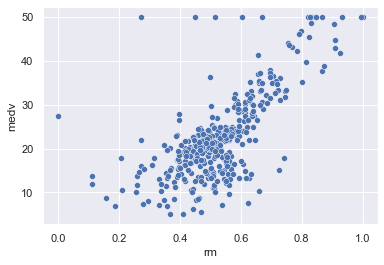

In [17]:
sns.scatterplot(data = X_train_export, x = "rm", y = target)
plt.show()

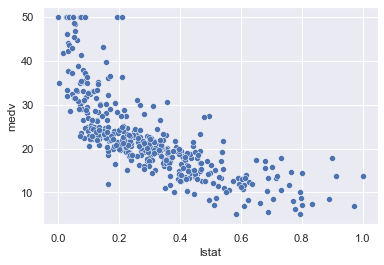

In [18]:
sns.scatterplot(data = X_train_export, x = "lstat", y = target)
plt.show()

In [19]:
X_train_export[['rm','lstat', target]].corr() #correlacion mas pronunciada

,rm,lstat,medv
rm,1.000000,-0.625729,0.711003
lstat,-0.625729,1.000000,-0.747278
medv,0.711003,-0.747278,1.000000


### Estimación del modelo de regresión

In [122]:
from sklearn.linear_model import LinearRegression

In [123]:
lr = LinearRegression()  # definimos el modelo

ahora para la variable 'rm'

In [124]:
lr.fit(X_train_export[['rm']], y_train.values)   # el ajuste de la recta de regresión

LinearRegression()

In [125]:
lr.coef_ #pendiente

array([49.38197007])

In [126]:
lr.intercept_ #intercepto

-3.4608002390451205

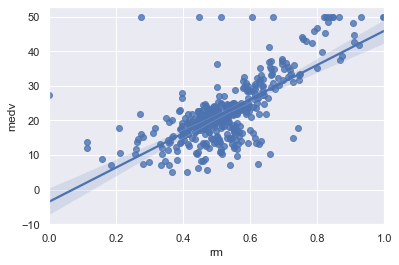

In [127]:
sns.regplot(x='rm', y='medv', data=X_train_export)
plt.show()

In [128]:
#R2 del train
lr.score(X_train_export[['rm']], y_train.values)

0.5055256766654072

In [129]:
#R2 del test
lr.score(X_test_export[['rm']], y_test.values)

0.3019509726980443

### Evaluación de regresión con MSE y RMSE

In [130]:
from sklearn.metrics import mean_squared_error, r2_score

obtenemos las predicciones del modelo para poder evaluarlas respecto a el target original

In [131]:
y_train_pred_rm = lr.predict(X_train_scaled[['rm']])
y_test_pred_rm = lr.predict(X_test_scaled[['rm']])

In [132]:
print('MSE train:', mean_squared_error(y_train, y_train_pred_rm))
print('MSE test:', mean_squared_error(y_test, y_test_pred_rm))

MSE train: 44.30740652186164
MSE test: 44.588792759415185


In [133]:
print('RMSE train:', mean_squared_error(y_train, y_train_pred_rm) ** 0.5)
print('RMSE test:', mean_squared_error(y_test, y_test_pred_rm) ** 0.5)

RMSE train: 6.656380887679253
RMSE test: 6.677484014163956


In [134]:
print('R2 train:', r2_score(y_train, y_train_pred_rm))
print('R2 test:', r2_score(y_test, y_test_pred_rm))

R2 train: 0.5055256766654072
R2 test: 0.3019509726980443


### ahora para la variable 'lstat'

In [135]:
lr.fit(X_train_export[['lstat']], y_train.values)   # el ajuste de la recta de regresión

LinearRegression()

In [136]:
lr.coef_ #pendiente

array([-35.46900535])

In [137]:
lr.intercept_ #intercepto

33.12549957580317

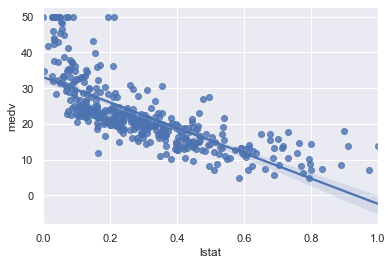

In [138]:
sns.regplot(x='lstat', y='medv', data=X_train_export)
plt.show()

In [139]:
#R2 del train
lr.score(X_train_export[['lstat']], y_train.values)

0.5584245218433206

In [140]:
#R2 del test
lr.score(X_test_export[['lstat']], y_test.values)

0.40593096853375843

In [141]:
X_train_export.shape

(404, 16)

In [142]:
X_test_export.shape

(102, 16)

### Evaluación de regresión con MSE y RMSE

In [143]:
from sklearn.metrics import mean_squared_error, r2_score

obtenemos las predicciones del modelo para poder evaluarlas respecto a el target original

In [144]:
y_train_pred_lstat = lr.predict(X_train_scaled[['lstat']])
y_test_pred_lstat = lr.predict(X_test_scaled[['lstat']])

In [145]:
print('MSE train:', mean_squared_error(y_train, y_train_pred_lstat))
print('MSE test:', mean_squared_error(y_test, y_test_pred_lstat))

MSE train: 39.56740177898876
MSE test: 37.946934803730414


In [146]:
print('RMSE train:', mean_squared_error(y_train, y_train_pred_lstat) ** 0.5)
print('RMSE test:', mean_squared_error(y_test, y_test_pred_lstat) ** 0.5)

RMSE train: 6.290262457083071
RMSE test: 6.160108343505852


In [247]:
rmse_fit_lineal=mean_squared_error(y_test, y_test_pred_lstat) ** 0.5
rmse_fit_lineal

6.160108343505852

In [248]:
print('R2 train:', r2_score(y_train, y_train_pred_lstat))
print('R2 test:', r2_score(y_test, y_test_pred_lstat))

R2 train: 0.5584245218433206
R2 test: 0.40593096853375843


In [249]:
r2_lineal=lr.score(X_test_export[['lstat']], y_test.values)
r2_lineal

0.40593096853375843

## 2. Regresión Múltiple

Utilizamos todas las variables para la predicción:

$$
ventas = \beta_0 + \beta_1 * area + \beta_2 *   publicidad\_ext + \beta_3    *  num\_productos + \beta_4 *  delivery 
$$


In [148]:
X_train_scaled.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis
0,0.016651,0.0,0.281525,0.314815,0.568164,0.942327,0.302367,0.130435,0.229008,0.893617,0.977407,0.301803,0.268402,0.344457,0.578083
1,0.004945,0.0,0.338343,0.411523,0.475988,0.642636,0.116351,0.217391,0.389313,0.702128,1.000000,0.305132,0.259693,0.422422,0.319098
2,0.000000,0.9,0.092009,0.030864,0.682998,0.184346,0.561767,0.000000,0.187023,0.287234,0.994503,0.164494,0.236037,0.511588,0.786597
3,1.000000,0.0,0.646628,0.633745,0.185515,1.000000,0.048068,1.000000,0.914122,0.808511,0.221771,0.972538,1.000000,0.268595,0.161729
4,0.002999,0.0,0.923387,0.403292,0.444423,0.969104,0.074094,0.043478,0.001908,0.691489,0.932952,0.651595,0.258245,0.070776,0.228811


In [149]:
X_test_scaled.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis
0,0.008901,0.0,0.379481,0.192389,0.426480,0.915778,0.274024,0.130435,0.186192,0.622222,0.990718,0.475520,0.229788,0.341191,0.513172
1,0.040764,0.0,0.278533,0.295983,0.419158,0.937100,0.330567,0.130435,0.248954,0.888889,0.993465,0.445838,0.220619,0.419544,0.574449
2,0.004639,0.0,0.188710,0.213531,0.402278,0.588486,0.220003,0.173913,0.190377,0.688889,0.950820,0.296206,0.195715,0.509155,0.446366
3,0.518899,0.0,0.688916,0.723044,0.358755,0.934968,0.051110,1.000000,1.000000,0.800000,1.000000,0.647185,1.000000,0.264951,0.145880
4,0.080225,0.0,0.749897,0.437632,0.737442,0.901919,0.067743,0.173913,0.449791,0.188889,0.942861,0.000000,0.219095,0.066146,0.185233


In [150]:
y_train.head()

0    18.4
1    21.2
2    32.2
3     7.0
4    17.3
Name: medv, dtype: float64

In [151]:
type(y_train)

pandas.core.series.Series

In [152]:
lr_multiple = LinearRegression()

In [153]:
lr_multiple.fit(X_train_scaled, y_train)

LinearRegression()

In [154]:
y_train_pred_multi = lr_multiple.predict(X_train_scaled)
y_test_pred_multi = lr_multiple.predict(X_test_scaled)

In [300]:
# The coefficients
print ('Coefficients: ', lr_multiple.coef_)
print ('Intercept: ',lr_multiple.intercept_)

Coefficients:  [-19.84357851   2.15318102  -1.59008971 -12.22022971  22.19607207
  -0.98448059  22.10748374   3.81382458  -8.91616847  -5.99174857
   3.09461597 -11.98121237  11.13136891  12.48770633 -40.61447234]
Intercept:  27.6274640432362


In [299]:
lr_multiple.intercept_

27.6274640432362

In [297]:
lr_multiple.intercept_

27.6274640432362

In [155]:
print('MSE train:', mean_squared_error(y_train, y_train_pred_multi))
print('MSE test:', mean_squared_error(y_test, y_test_pred_multi))

MSE train: 19.86454510279359
MSE test: 42.82787245643599


In [156]:
print('RMSE train:', mean_squared_error(y_train, y_train_pred_multi) ** 0.5)
print('RMSE test:', mean_squared_error(y_test, y_test_pred_multi) ** 0.5)

RMSE train: 4.456965907744145
RMSE test: 6.54430076145924


In [157]:
rmse_fit=mean_squared_error(y_test, y_test_pred_multi) ** 0.5
rmse_fit                         

6.54430076145924

In [158]:
print('R2 train:', r2_score(y_train, y_train_pred_multi))
print('R2 test:', r2_score(y_test, y_test_pred_multi))

R2 train: 0.7783100328111767
R2 test: 0.3295186332822465


In [159]:
r2_fit=r2_score(y_test, y_test_pred_multi)
r2_fit

0.3295186332822465

In [160]:
#nos da los coeficientes del modelo
betas = pd.DataFrame({'features': X_train_scaled.columns, 'beta': lr_multiple.coef_})
betas

,features,beta
0,crim,-19.843579
1,zn,2.153181
2,indus,-1.590090
3,nox,-12.220230
4,rm,22.196072
5,edad,-0.984481
6,dis,22.107484
7,rad,3.813825
8,impuesto,-8.916168
9,ptratio,-5.991749


In [161]:
X_train_scaled.shape

(404, 15)

# <u>Métodos Supervisados para Regresión - Librería Sklearn y Statsmodels</u>

In [163]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline

<AxesSubplot:>

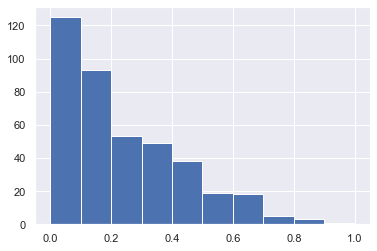

In [167]:
X_train_export['dis'].hist()

array([[<AxesSubplot:title={'center':'crim'}>,
        <AxesSubplot:title={'center':'zn'}>,
        <AxesSubplot:title={'center':'indus'}>,
        <AxesSubplot:title={'center':'nox'}>],
       [<AxesSubplot:title={'center':'rm'}>,
        <AxesSubplot:title={'center':'edad'}>,
        <AxesSubplot:title={'center':'dis'}>,
        <AxesSubplot:title={'center':'rad'}>],
       [<AxesSubplot:title={'center':'impuesto'}>,
        <AxesSubplot:title={'center':'ptratio'}>,
        <AxesSubplot:title={'center':'negro'}>,
        <AxesSubplot:title={'center':'lstat'}>],
       [<AxesSubplot:title={'center':'Índice_de_criminalidad'}>,
        <AxesSubplot:title={'center':'In_calidad_vida'}>,
        <AxesSubplot:title={'center':'log_dis'}>,
        <AxesSubplot:title={'center':'medv'}>]], dtype=object)

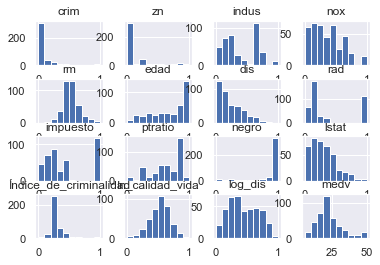

In [168]:
X_train_export.hist()

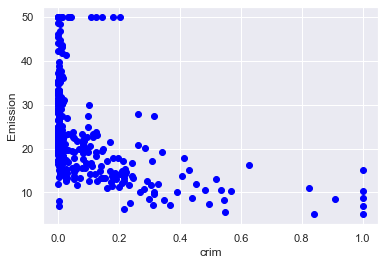

In [169]:
plt.scatter(X_train_export.crim, X_train_export.medv,  color='blue')
plt.xlabel("crim")
plt.ylabel("Emission")
plt.show()

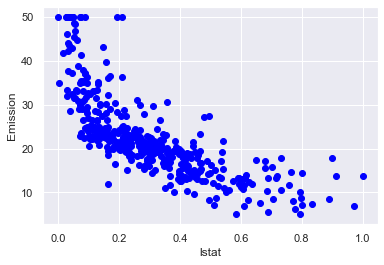

In [170]:
plt.scatter(X_train_export.lstat, X_train_export.medv,  color='blue')
plt.xlabel("lstat")
plt.ylabel("Emission")
plt.show()

<h2 id="multiple_regression">Modelo de regresión Múltiple</h2>

In [176]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
regr.fit (X_train_scaled, y_train)

LinearRegression()

In [177]:
regr.intercept_

27.6274640432362

In [178]:
regr.coef_

array([-19.84357851,   2.15318102,  -1.59008971, -12.22022971,
        22.19607207,  -0.98448059,  22.10748374,   3.81382458,
        -8.91616847,  -5.99174857,   3.09461597, -11.98121237,
        11.13136891,  12.48770633, -40.61447234])

In [179]:
# The coefficients
print ('Coefficients: ', regr.coef_)
print ('Intercept: ',regr.intercept_)

Coefficients:  [-19.84357851   2.15318102  -1.59008971 -12.22022971  22.19607207
  -0.98448059  22.10748374   3.81382458  -8.91616847  -5.99174857
   3.09461597 -11.98121237  11.13136891  12.48770633 -40.61447234]
Intercept:  27.6274640432362


#### Mínimos Cuadrados Ordinarios/Ordinary Least Squares (OLS)

In [180]:
regr.score(X_train_scaled,y_train) # R2

0.7783100328111767

In [181]:
y_hat= regr.predict(X_test_scaled)

In [182]:
y_hat

array([ 17.57303314,  13.49622013,  22.4788484 ,   9.53184336,
        30.6537096 ,  12.55853313,  29.31850322,  26.98384351,
        24.72148021,  37.55427962,  31.74505085,  27.13517126,
        14.56082589,  41.76071606,  31.1750724 ,  25.59578724,
        27.06964246,  -2.81228355, -11.69730754,  31.6686541 ,
        19.9529743 ,  15.12632951,  13.09737394,  28.13022025,
         8.46943159,  13.46485791,  26.94782181,  27.65930647,
        29.24599017,  15.22817831,  19.64992183,  31.0657958 ,
        19.46227336,  27.54638983,  25.12526919,  22.23269969,
        27.20190819,   8.05739994,  30.06258892,  19.99021931,
        20.89245033,  23.09353341,  26.92466179,  31.7287684 ,
        10.36634479,  33.29672408,  20.31791184,  32.30224468,
        26.55407798,  28.6773807 ,   7.96321526,  40.08395252,
        18.58198413,  31.38065068,  16.44992591,  21.33669184,
        23.38904345,  22.13140603,  30.21277998,  23.83039759,
        36.90905713,  18.07273121,   8.55163967,  22.70

In [183]:
y_hat= regr.predict(X_test_scaled)
X_test_scaled
y_test
print("Mean absolute error: %.2f" % np.mean(np.absolute(y_hat - y_test)))
print("Residual sum of squares: %.2f"
      % np.mean((y_hat - y_test) ** 2))

# Explained variance score: 1 is perfect prediction
print('R2-score: %.2f' % regr.score(X_test_scaled, y_test))

Mean absolute error: 4.82
Residual sum of squares: 42.83
R2-score: 0.33


ahora con statsmodels

In [185]:
# modelo de regresión líneal con statsmodels

import statsmodels.api as sm           
import statsmodels.formula.api as smf  

M_R = sm.OLS(y_train,X_train_scaled).fit()
M_R.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.770
Method:                 Least Squares   F-statistic:                     97.55
Date:                Thu, 28 Sep 2023   Prob (F-statistic):          1.05e-117
Time:                        09:01:22   Log-Likelihood:                -1177.0
No. Observations:                 404   AIC:                             2384.
Df Residuals:                     389   BIC:                             2444.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
crim                     -19.8436      6.101     -3.253      0.001     -31.838      -7.849
zn                         2.1532      1.574      1.368      0.172      -0.942       5.248
indus                     -1.5901      1.835     -0.867      0.387      -5.197       2.017
nox                      -11.8069      2.021     -5.843      0.000     -15.780      -7.834
rm                        22.1961      2.381      9.321      0.000      17.514      26.878
edad                      -0.9845      1.470     -0.670      0.503      -3.874       1.905
dis                       22.1075      5.755      3.841      0.000      10.793      33.422
rad                      -15.7475      2.796     -5.632      0.000     -21.245     -10.250
impuesto                  -8.9162      2.047     -4.355      0.000     -12.941      -4.891
ptratio                    2.0029      1.605      1.248      0.213      -1.152       5.158
negro                      3.0946      1.129      2.742      0.006       0.876       5.314
lstat                     18.6791      3.859      4.841      0.000      11.092      26.266
Índice_de_criminalidad    11.1314      7.474      1.489      0.137      -3.563      25.826
In_calidad_vida           52.1191      4.937     10.556      0.000      42.412      61.826
log_dis                  -40.6145      5.429     -7.481      0.000     -51.289     -29.940
==============================================================================
Omnibus:                       62.412   Durbin-Watson:                   1.824
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              153.602
Skew:                           0.770   Prob(JB):                     4.42e-34
Kurtosis:                       5.598   Cond. No.                         83.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [186]:
# Predicción del test
y_pred_anova = M_R.predict(X_test_scaled)

In [187]:
y_pred_anova.describe()

count    102.000000
mean      21.932598
std       14.077500
min      -25.835480
25%       15.496721
50%       25.315900
75%       31.808642
max       46.794158
dtype: float64

In [188]:
y_test.describe()

count    102.000000
mean      22.472549
std        8.031734
min        7.200000
25%       18.925000
50%       21.650000
75%       24.800000
max       50.000000
Name: medv, dtype: float64

In [189]:
from sklearn import metrics

In [190]:
# Evaluación del modelo
print('Mean Absolute Error:',      metrics.mean_absolute_error(y_test, y_pred_anova))  
print('Mean Squared Error:',       metrics.mean_squared_error(y_test, y_pred_anova))  
print('Root Mean Squared Error:',  np.sqrt(metrics.mean_squared_error(y_test, y_pred_anova)))

rmse_ols = np.sqrt(metrics.mean_squared_error(y_test, y_pred_anova))
print(f"El error (rmse) de test es: {rmse_ols}")

Mean Absolute Error: 10.347582089131606
Mean Squared Error: 182.84530942225317
Root Mean Squared Error: 13.522030521421447
El error (rmse) de test es: 13.522030521421447


# <u>Análisis de Regresión y Regularizaciones</u>

In [193]:
# Import necessary libs

import pandas as pd
import numpy as np
from sklearn import preprocessing
from math import sqrt

import warnings
warnings.filterwarnings('ignore')
from scipy import stats

## Modelos de regresion
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
import statsmodels.api as sm           
import statsmodels.formula.api as smf  

# visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Metricas de evaluación
from sklearn.metrics import mean_squared_error
from sklearn import metrics
from sklearn.metrics import r2_score

#separar train and test
from sklearn.model_selection import train_test_split

# estadística y matemáticas
#import pandas as pd
import scipy.stats as scy
from scipy.stats import kurtosis

In [194]:
X_train_export["medv"].describe()

count    404.000000
mean      22.548020
std        9.477733
min        5.000000
25%       16.600000
50%       20.950000
75%       25.150000
max       50.000000
Name: medv, dtype: float64

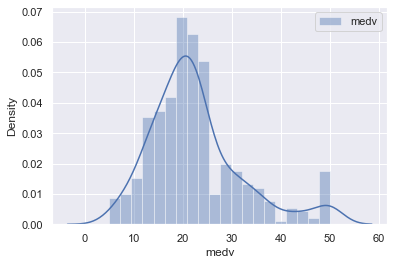

In [195]:
# Histograma del Target
sns.set()
plt.figure()
sns.distplot(X_train_export["medv"] , label="medv")
plt.legend()
plt.show()

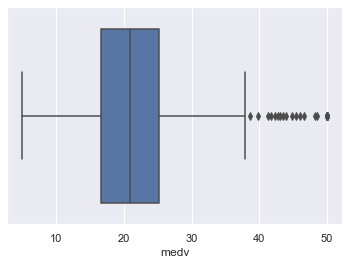

In [196]:
# Grouped boxplot
plt.figure()
sns.boxplot(x='medv', data=X_train_export);

In [197]:
X_train_export.head()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis,medv
0,0.016651,0.0,0.281525,0.314815,0.568164,0.942327,0.302367,0.130435,0.229008,0.893617,0.977407,0.301803,0.268402,0.344457,0.578083,18.4
1,0.004945,0.0,0.338343,0.411523,0.475988,0.642636,0.116351,0.217391,0.389313,0.702128,1.000000,0.305132,0.259693,0.422422,0.319098,21.2
2,0.000000,0.9,0.092009,0.030864,0.682998,0.184346,0.561767,0.000000,0.187023,0.287234,0.994503,0.164494,0.236037,0.511588,0.786597,32.2
3,1.000000,0.0,0.646628,0.633745,0.185515,1.000000,0.048068,1.000000,0.914122,0.808511,0.221771,0.972538,1.000000,0.268595,0.161729,7.0
4,0.002999,0.0,0.923387,0.403292,0.444423,0.969104,0.074094,0.043478,0.001908,0.691489,0.932952,0.651595,0.258245,0.070776,0.228811,17.3


In [198]:
X_train_export.describe()

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis,medv
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,0.081527,0.115545,0.396108,0.356398,0.526687,0.681746,0.240432,0.385708,0.435294,0.623973,0.896188,0.298218,0.301868,0.527190,0.444546,22.548020
std,0.168474,0.237853,0.257139,0.245986,0.136461,0.287970,0.194198,0.385862,0.327754,0.232482,0.233842,0.199681,0.137110,0.170768,0.231265,9.477733
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
25%,0.001521,0.000000,0.171188,0.129630,0.450571,0.441813,0.086161,0.130435,0.185115,0.507979,0.945969,0.136477,0.243637,0.422389,0.256625,16.600000
50%,0.006160,0.000000,0.338343,0.314815,0.512684,0.778579,0.177295,0.173913,0.293893,0.691489,0.985892,0.265465,0.259709,0.535570,0.422506,20.950000
75%,0.090230,0.125000,0.646628,0.514403,0.593532,0.941555,0.373278,1.000000,0.914122,0.808511,0.998273,0.415811,0.323144,0.649180,0.646045,25.150000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,50.000000


In [199]:
X_train_export.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   crim                    404 non-null    float64
 1   zn                      404 non-null    float64
 2   indus                   404 non-null    float64
 3   nox                     404 non-null    float64
 4   rm                      404 non-null    float64
 5   edad                    404 non-null    float64
 6   dis                     404 non-null    float64
 7   rad                     404 non-null    float64
 8   impuesto                404 non-null    float64
 9   ptratio                 404 non-null    float64
 10  negro                   404 non-null    float64
 11  lstat                   404 non-null    float64
 12  Índice_de_criminalidad  404 non-null    float64
 13  In_calidad_vida         404 non-null    float64
 14  log_dis                 404 non-null    fl

### Correlaciones lineales

In [200]:
X_train_export.corr(method='pearson')

,crim,zn,indus,nox,rm,edad,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis,medv
crim,1.000000,-0.231547,0.451260,0.459431,-0.288268,0.399065,-0.427309,0.693083,0.642874,0.329041,-0.419252,0.538391,0.962655,0.188677,-0.517307,-0.424797
zn,-0.231547,1.000000,-0.535440,-0.521465,0.344034,-0.573572,0.672939,-0.330044,-0.338358,-0.407102,0.178364,-0.423101,-0.332833,0.134290,0.597587,0.373858
indus,0.451260,-0.535440,1.000000,0.765171,-0.414616,0.652778,-0.712682,0.596789,0.728952,0.390534,-0.347090,0.619428,0.521162,-0.013508,-0.762216,-0.484888
nox,0.459431,-0.521465,0.765171,1.000000,-0.351672,0.738444,-0.769248,0.599936,0.658154,0.181371,-0.376447,0.612007,0.473827,0.050629,-0.829524,-0.433230
rm,-0.288268,0.344034,-0.414616,-0.351672,1.000000,-0.271275,0.236376,-0.241962,-0.333335,-0.357203,0.125205,-0.625729,-0.345259,0.399576,0.295639,0.711003
edad,0.399065,-0.573572,0.652778,0.738444,-0.271275,1.000000,-0.762166,0.473810,0.517774,0.282422,-0.275295,0.628061,0.426092,-0.128382,-0.791542,-0.378956
dis,-0.427309,0.672939,-0.712682,-0.769248,0.236376,-0.762166,1.000000,-0.508928,-0.541710,-0.242627,0.288597,-0.513650,-0.467991,-0.024750,0.964598,0.251618
rad,0.693083,-0.330044,0.596789,0.599936,-0.241962,0.473810,-0.508928,1.000000,0.905502,0.480901,-0.433696,0.509528,0.694987,0.513273,-0.568954,-0.365453
impuesto,0.642874,-0.338358,0.728952,0.658154,-0.333335,0.517774,-0.541710,0.905502,1.000000,0.479624,-0.428394,0.569635,0.664882,0.352982,-0.620967,-0.465480
ptratio,0.329041,-0.407102,0.390534,0.181371,-0.357203,0.282422,-0.242627,0.480901,0.479624,1.000000,-0.177400,0.376037,0.424291,-0.081184,-0.240016,-0.485677


(16.0, 0.0)

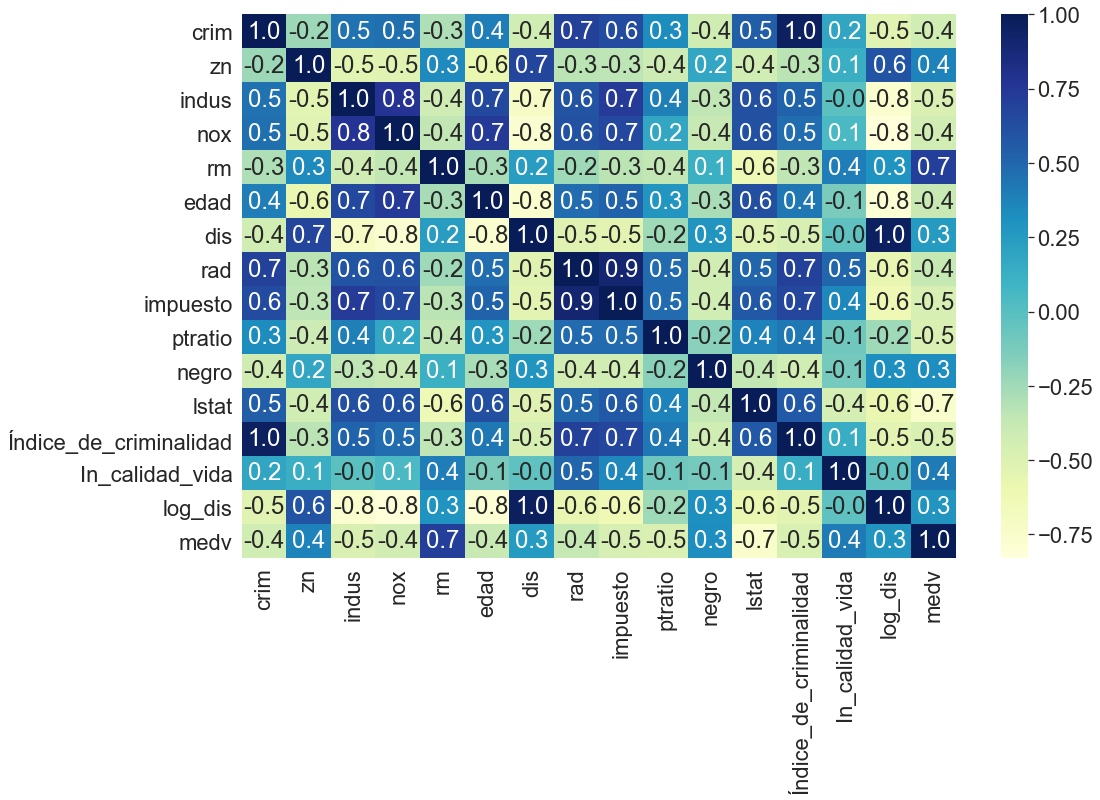

In [201]:
sns.set(font_scale=2)
corr_matrix = X_train_export.corr()
plt.figure(figsize=(16, 10))
ax = sns.heatmap(corr_matrix,annot=True, fmt=".1f",cmap="YlGnBu") 
ax.set_ylim(sorted(ax.get_xlim(), reverse=True))

### Distribución de las variables cuantitativas 

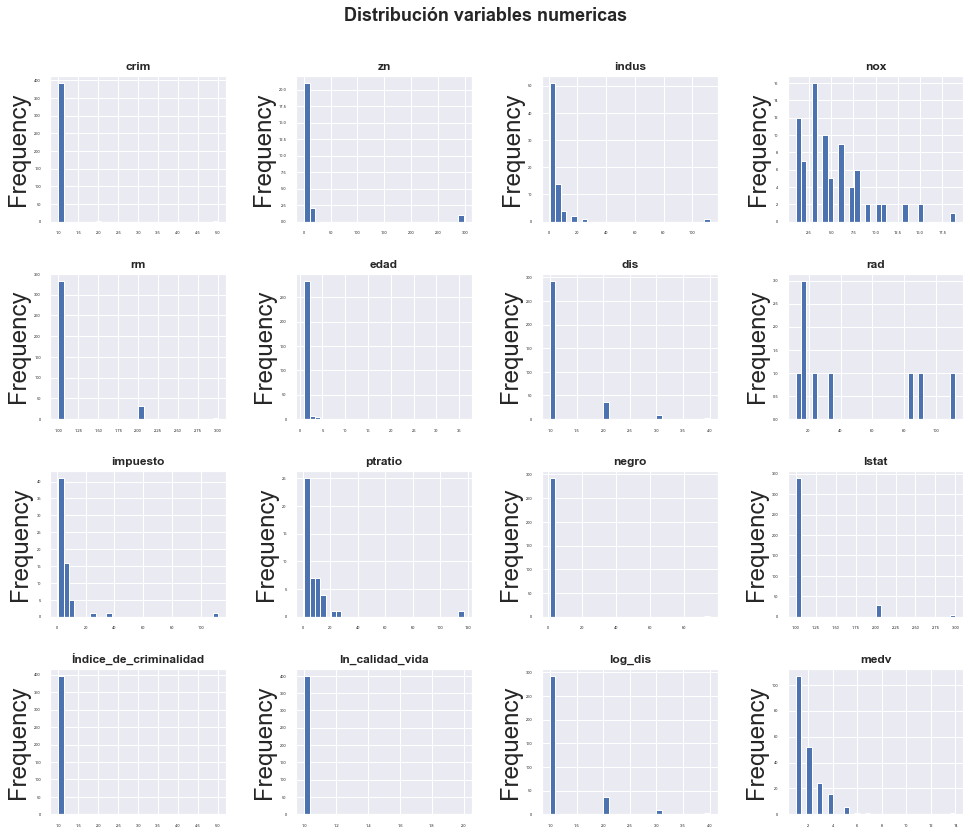

In [202]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(14, 12))
axes = axes.flat
columnas_object = X_train_export.select_dtypes(include=['float']).columns

for i, colum in enumerate(columnas_object):
    X_train_export[colum].value_counts().plot.hist(ax = axes[i], bins=30)
    axes[i].set_title(colum, fontsize = 12, fontweight = "bold")
    axes[i].tick_params(labelsize = 4)
    axes[i].set_xlabel("")

fig.tight_layout()
plt.subplots_adjust(top=0.9)
fig.suptitle('Distribución variables numericas',
             fontsize = 18, fontweight = "bold");

### Analisis Residual y Supuestos 

Text(0, 0.5, 'Predicción')

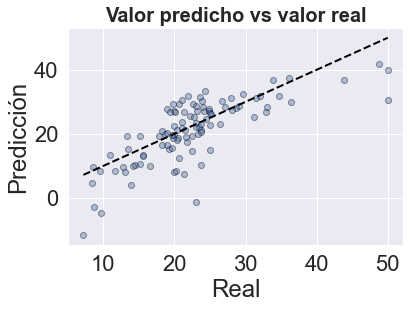

In [203]:
# Valores predecidos vs valores reales (Linealidad)
plt.scatter(y_test, y_test_pred_multi, edgecolors=(0, 0, 0), alpha = 0.4)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()],'k--', color = 'black', lw=2)
plt.title('Valor predicho vs valor real', fontsize = 20, fontweight = "bold")
plt.xlabel('Real')
plt.ylabel('Predicción')

In [204]:
## Prueba de normalidad 
from scipy.stats import shapiro
stat, p = shapiro(y_test.index.values - np.array(y_test_pred_multi))
print('Statistics=%.3f, p=%.3f' % (stat, p))

Statistics=0.963, p=0.006


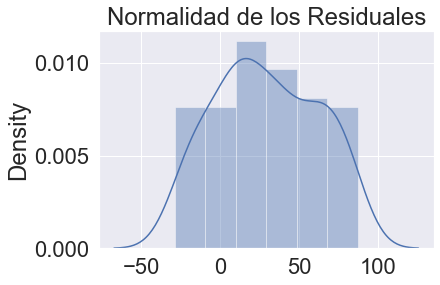

In [205]:
# Normalidad
p = sns.distplot(y_test.index.values - np.array(y_test_pred_multi),kde=True)
p = plt.title('Normalidad de los Residuales')
plt.show()

La multicolinealidad en el análisis de regresión ocurre cuando dos o más variables explicativas están altamente correlacionadas entre sí, de manera que no brindan información única o independiente en el modelo de regresión. Si el grado de correlación entre variables es lo suficientemente alto, puede causar problemas al ajustar e interpretar el modelo de regresión.

Una forma de detectar la multicolinealidad es mediante el uso de una métrica conocida como factor de inflación de la varianza (VIF) , que mide la correlación y la fuerza de la correlación entre las variables explicativas en un modelo de regresión .

In [206]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#calcular VIF para cada variable explicativa
vif = pd.DataFrame ()
vif ['VIF'] = [variance_inflation_factor(X_train_scaled.values, i) for i in range (X_train_scaled.shape[1])]
vif ['variable'] = X_train_scaled.columns

#ver VIF para cada variable explicativa 
vif

,VIF,variable
0,20.635061,crim
1,2.738299,zn
2,4.346905,indus
3,14.981194,nox
4,2.062839,rm
5,3.499820,edad
6,24.399856,dis
7,45.516557,rad
8,8.794781,impuesto
9,22.351185,ptratio


El valor de VIF comienza en 1 y no tiene límite superior. Una regla general para interpretar los VIF es la siguiente:

Un valor de 1 indica que no hay correlación entre una variable explicativa dada y cualquier otra variable explicativa en el modelo.
Un valor entre 1 y 5 indica una correlación moderada entre una variable explicativa dada y otras variables explicativas en el modelo, pero esto a menudo no es lo suficientemente grave como para requerir atención.
Un valor mayor que 5 indica una correlación potencialmente severa entre una variable explicativa dada y otras variables explicativas en el modelo. En este caso, las estimaciones de los coeficientes y los valores p en el resultado de la regresión probablemente no sean confiables.

## 4.Modelos lineales con Regularización

In [207]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV

## 4.1 Regularización Ridge

In [208]:
# Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)
# Por defecto RidgeCV utiliza el mean squared error
modelo_RG = RidgeCV(
            alphas          = [50,40,30,20,10,8,6,4,2,1,0.8,0.60,0.30,0.15,0.10,0.005,0.0001,0.00005],
            fit_intercept   = True,
            #normalize       = True,
            store_cv_values = True
         )

_ = modelo_RG.fit(X = X_train_scaled, y = y_train)

In [209]:
modelo_RG

RidgeCV(alphas=[50, 40, 30, 20, 10, 8, 6, 4, 2, 1, 0.8, 0.6, 0.3, 0.15, 0.1,
                0.005, 0.0001, 5e-05],
        store_cv_values=True)

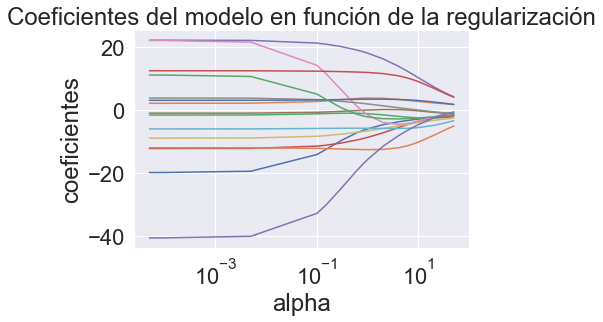

In [210]:
# Evolución de los coeficientes en función de alpha
alphas = modelo_RG.alphas
coefs = []

for alpha in alphas:
    modelo_temp = Ridge(alpha=alpha, fit_intercept=True)
    modelo_temp.fit(X_train_scaled, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots()
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización');
plt.axis('tight')
plt.show()

In [211]:
# el valor de alpha es:
modelo_RG.alpha_

0.005

In [212]:
# Mejor modelo alpha óptimo + 1sd
modelo_RG = Ridge(alpha=0.1)
modelo_RG.fit(X_train_scaled, y_train)

Ridge(alpha=0.1)

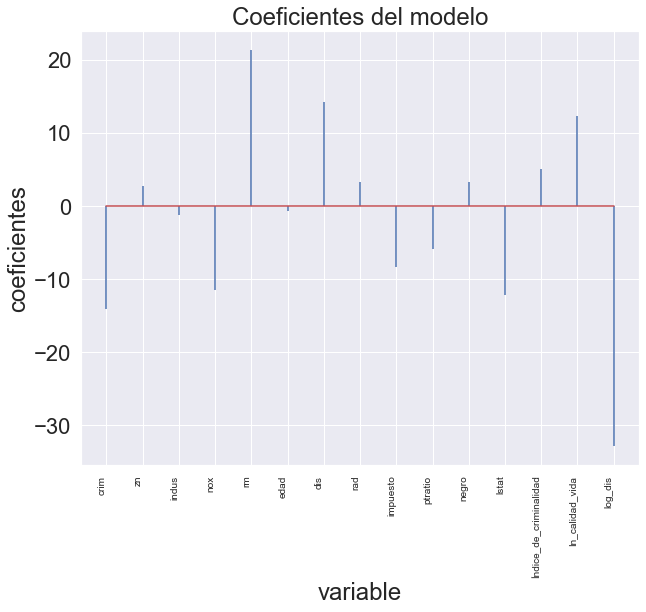

In [213]:
# Coeficientes del modelo
# ==============================================================================
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train_scaled.columns,
                         'coef': modelo_RG.coef_.flatten()})

fig, ax = plt.subplots(figsize=(10, 8))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo');

In [214]:
# Pintamos los coeficientes
print(pd.Series(modelo_RG.coef_.ravel(), index = X_train_scaled.columns).sort_values(ascending = False))

rm                        21.283263
dis                       14.210565
In_calidad_vida           12.357429
Índice_de_criminalidad     5.078605
rad                        3.320853
negro                      3.216551
zn                         2.721315
edad                      -0.710975
indus                     -1.203058
ptratio                   -5.845735
impuesto                  -8.324873
nox                      -11.461024
lstat                    -12.175642
crim                     -14.123212
log_dis                  -32.816071
dtype: float64


In [215]:
# Predicciones del test
predicciones = modelo_RG.predict(X=X_test_scaled)
predicciones = predicciones.flatten()
predicciones[:10]

array([17.80223109, 14.11857535, 22.66920726,  7.55842551, 30.66274254,
       14.07826117, 29.105196  , 27.15301354, 23.40360168, 36.81512161])

In [216]:
# Error de test del modelo 
rmse_ridge = np.sqrt(metrics.mean_squared_error(y_test, predicciones))
print("")
print(f"El ECM de test es: {rmse_ridge}")


El ECM de test es: 5.768640477766461


In [217]:
# R2 del modelo 
r2_ridge = np.sqrt(r2_score(y_test,predicciones))
print("")
print(f"El error (rmse) de test es: {r2_ridge}")


El error (rmse) de test es: 0.6921247473571343


## 4.2 Regularización Lasso

In [257]:
# Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)
# Por defecto LassoCV utiliza el mean squared error
modelo_LS = LassoCV(
            alphas          = [100,80,60,30,15,10,9,8,7,6,5,1,0.1,0.01,0.001],
            cv              = 10
         )
_ = modelo_LS.fit(X = X_train_scaled, y = y_train)

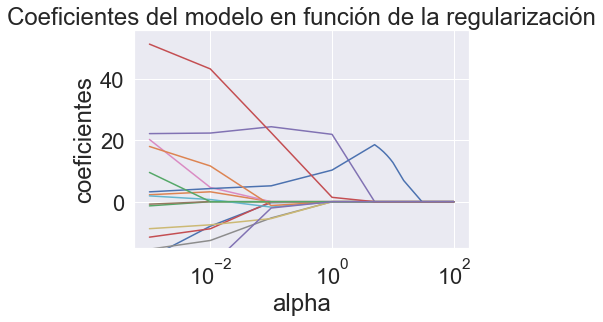

In [258]:
# Evolución de los coeficientes en función de alpha
alphas = modelo_LS.alphas_
coefs = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train_scaled, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots()
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_ylim([-15,None])
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización');

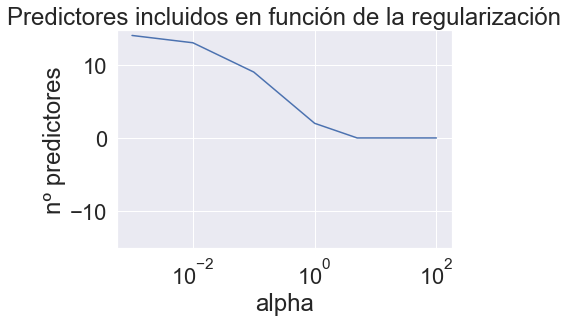

In [259]:
# Número de predictores incluidos (coeficiente !=0) en función de alpha
alphas = modelo_LS.alphas_
n_predictores = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=True)
    modelo_temp.fit(X_train_scaled, y_train)
    coef_no_cero = np.sum(modelo_temp.coef_.flatten() != 0)
    n_predictores.append(coef_no_cero)

fig, ax = plt.subplots()
ax.plot(alphas, n_predictores)
ax.set_xscale('log')
ax.set_ylim([-15,None])
ax.set_xlabel('alpha')
ax.set_ylabel('nº predictores')
ax.set_title('Predictores incluidos en función de la regularización');

In [260]:
# el valor de alpha es:
modelo_LS.alpha_

0.001

In [261]:
# Mejor modelo alpha óptimo + 1sd
modelo_LS = Lasso(alpha=0.05)
modelo_LS.fit(X_train_scaled, y_train)

Lasso(alpha=0.05)

In [262]:
# Coeficientes del modelo
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train_scaled.columns,
                         'coef': modelo_LS.coef_.flatten()}
                  )

# Predictores incluidos en el modelo (coeficiente != 0)
df_coeficientes[df_coeficientes.coef != 0]

,predictor,coef
0,crim,-4.190266
1,zn,2.299103
3,nox,-6.595147
4,rm,19.979698
8,impuesto,-5.391417
9,ptratio,-5.377123
10,negro,3.066185
11,lstat,-13.260124
13,In_calidad_vida,11.442514
14,log_dis,-12.872751


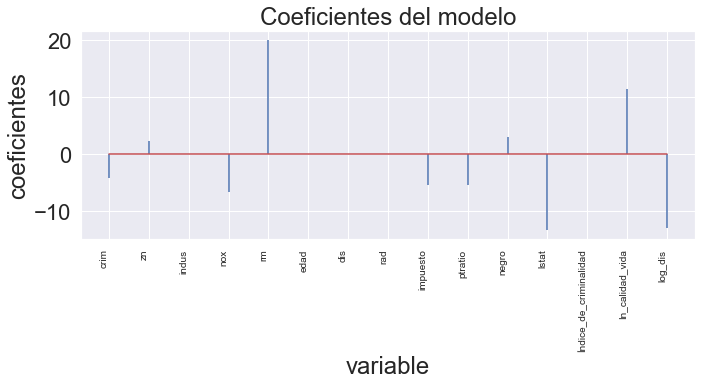

In [263]:
fig, ax = plt.subplots(figsize=(11, 3.84))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo');

In [264]:
# Pintamos los coeficientes
print(pd.Series(modelo_LS.coef_, index = X_train_scaled.columns).sort_values(ascending = False))

rm                        19.979698
In_calidad_vida           11.442514
negro                      3.066185
zn                         2.299103
indus                     -0.000000
edad                      -0.000000
dis                       -0.000000
rad                        0.000000
Índice_de_criminalidad    -0.000000
crim                      -4.190266
ptratio                   -5.377123
impuesto                  -5.391417
nox                       -6.595147
log_dis                  -12.872751
lstat                    -13.260124
dtype: float64


In [265]:
# Predicciones test
predicciones = modelo_LS.predict(X=X_test_scaled)
predicciones = predicciones.flatten()
predicciones[:10]

array([17.94577468, 15.72024139, 21.99693425,  7.22022728, 30.38431798,
       16.02421388, 27.81621504, 26.87883064, 22.18219467, 34.30533844])

In [266]:
# Error de test del modelo 
rmse_lasso = np.sqrt(metrics.mean_squared_error(y_test, predicciones))
print("")
print(f"El error (rmse) de test es: {rmse_lasso}")


El error (rmse) de test es: 5.135058622732636


In [267]:
# R2 del modelo 
r2_lasso = np.sqrt(r2_score(y_test,predicciones))
print("")
print(f"El R2 de test es: {r2_lasso}")


El R2 de test es: 0.7662827319949618


## 4.3 Regularización Elastic net

In [273]:
# Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)
# Por defecto ElasticNetCV utiliza el mean squared error
modelo_EL = ElasticNetCV(
            l1_ratio        = [0, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
            alphas          = [1000,800,600,400,200,100,80,60,30,15,10,9,8,7,6,5,1,0.1,0.01,0.001],
            cv              = 10
         )
_ = modelo_EL.fit(X = X_train_scaled, y = y_train)

In [274]:
modelo_EL

ElasticNetCV(alphas=[1000, 800, 600, 400, 200, 100, 80, 60, 30, 15, 10, 9, 8, 7,
                     6, 5, 1, 0.1, 0.01, 0.001],
             cv=10, l1_ratio=[0, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99])

In [275]:
modelo_EL.l1_ratio_  #ratio de ridge

0.9

In [276]:
modelo_EL.alpha_

0.001

In [282]:
# Coeficientes del modelo
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train_scaled.columns,
                         'coef': modelo_EL.coef_.flatten()}
                  )

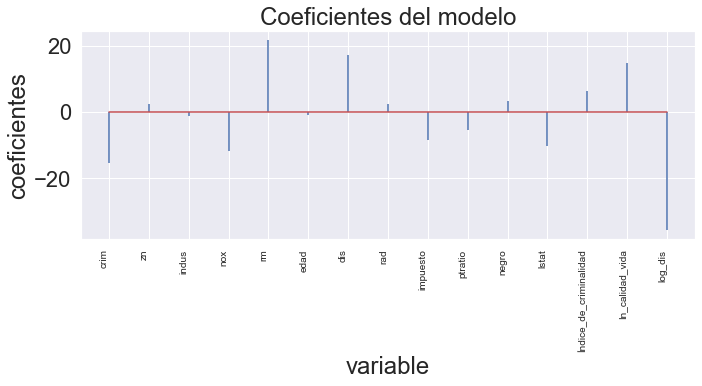

In [278]:
fig, ax = plt.subplots(figsize=(11, 3.84))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo');

In [283]:
# Pintamos los coeficientes
print(pd.Series(modelo_EL.coef_, index = X_train_scaled.columns).sort_values(ascending = False))

rm                        21.640331
dis                       17.124478
In_calidad_vida           14.784723
Índice_de_criminalidad     6.242846
negro                      3.148999
zn                         2.444201
rad                        2.252880
edad                      -0.811482
indus                     -1.282578
ptratio                   -5.360071
impuesto                  -8.485235
lstat                    -10.282687
nox                      -11.750205
crim                     -15.395750
log_dis                  -35.678109
dtype: float64


In [284]:
# Predicciones test
predicciones = modelo_EL.predict(X=X_test_scaled)
predicciones = predicciones.flatten()

In [285]:
# Error de test del modelo 
rmse_elastic = np.sqrt(mean_squared_error(y_test,predicciones))
print("")
print(f"El error (rmse) de test es: {rmse_elastic}")


El error (rmse) de test es: 6.168157502665261


In [286]:
# R2 del modelo 
r2_elastic = np.sqrt(r2_score(y_test,predicciones))
print("")
print(f"El R2 de test es: {r2_elastic}")


El R2 de test es: 0.6359068039494805


### COMPARACION DEL MEJOR MODELO EN BASE AL RMSE

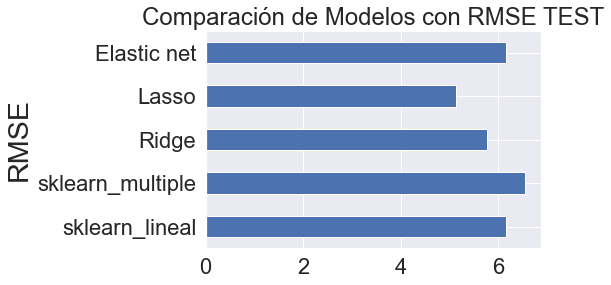

In [287]:
# Comparamos los 4 modelos
df_comparacion1 = pd.DataFrame({
                    'modelo': ['sklearn_lineal','sklearn_multiple', 'Ridge', 'Lasso','Elastic net'],
                    'test rmse': [rmse_fit_lineal,rmse_fit, rmse_ridge, rmse_lasso,rmse_elastic]
                 })
ax = df_comparacion1.set_index('modelo').plot(kind="barh",title="Comparación de Modelos con RMSE TEST")
ax.set_ylabel("RMSE", fontsize="large")
ax.get_legend().remove()

In [288]:
df_comparacion1

,modelo,test rmse
0,sklearn_lineal,6.160108
1,sklearn_multiple,6.544301
2,Ridge,5.768640
3,Lasso,5.135059
4,Elastic net,6.168158


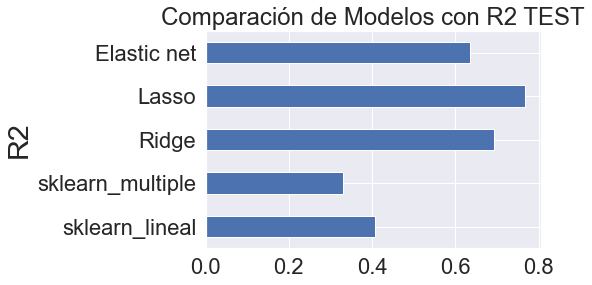

In [289]:
# Comparamos los 4 modelos
df_comparacion2 = pd.DataFrame({
                    'modelo': ['sklearn_lineal','sklearn_multiple', 'Ridge', 'Lasso','Elastic net'],
                    'test rmse': [r2_lineal,r2_fit, r2_ridge, r2_lasso,r2_elastic]
                 })
ax = df_comparacion2.set_index('modelo').plot(kind="barh",title="Comparación de Modelos con R2 TEST")
ax.set_ylabel("R2", fontsize="large")
ax.get_legend().remove()

In [290]:
df_comparacion2

,modelo,test rmse
0,sklearn_lineal,0.405931
1,sklearn_multiple,0.329519
2,Ridge,0.692125
3,Lasso,0.766283
4,Elastic net,0.635907


eliminar columnas edad y ind